<a href="https://colab.research.google.com/github/mukedon/quantum_computing/blob/main/quantum_error_correction/1_quantum_computing_errors/quantum_computing_errors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Quantum Computing Errors

## Overview

Before we can understand how to *correct* quantum errors, we must understand what
quantum errors *are*, where they come from, and why they are fundamentally different
from classical errors.

This chapter covers:

| Section | Topic |
|---|---|
| 1.1 | Why QEC is necessary — motivation and the no-cloning theorem |
| 1.2 | The Pauli error basis — why any error decomposes into X, Y, Z |
| 1.3 | Bit-flip errors ($X$ errors) |
| 1.4 | Phase-flip errors ($Z$ errors) |
| 1.5 | Bit-phase flip errors ($Y$ errors) and the depolarizing channel |
| 1.6 | Decoherence — $T_1$, $T_2$, amplitude damping, and dephasing |
| 1.7 | Gate errors and measurement errors |
| 1.8 | Physical origins by hardware platform |

**Prerequisites:** Basic linear algebra, Dirac notation, density matrices.
Familiarity with the Bloch sphere is helpful but not required.

**Libraries used in this chapter:**
```python
numpy, scipy, matplotlib, qiskit, qiskit-aer
```

---

**Key references for this chapter:**

| # | Reference |
|---|---|
| [1] | Nielsen, M. A. & Chuang, I. L. *Quantum Computation and Quantum Information*. Cambridge University Press, 2010. |
| [2] | Quillen, A. C. *Introducing Quantum Error Correction* (PHY265 lecture notes). University of Rochester, 2025. https://astro.pas.rochester.edu/~aquillen/phy265/lectures/QI_E.pdf |
| [3] | Preskill, J. *Lecture Notes for Ph219/CS219: Quantum Information, Chapter 3*. Caltech, 2015. https://www.preskill.caltech.edu/ph219/chap3_15.pdf |
| [4] | Wootters, W. K. & Zurek, W. H. A single quantum cannot be cloned. *Nature* **299**, 802–803 (1982). |
| [5] | Lindblad, G. On the generators of quantum dynamical semigroups. *Commun. Math. Phys.* **48**, 119–130 (1976). |
| [6] | Shor, P. W. Scheme for reducing decoherence in quantum computer memory. *Phys. Rev. A* **52**, R2493 (1995). |
| [7] | Steane, A. M. Error correcting codes in quantum theory. *Phys. Rev. Lett.* **77**, 793 (1996). |
| [8] | Gottesman, D. *Stabilizer Codes and Quantum Error Correction* (PhD thesis). Caltech, 1997. https://arxiv.org/abs/quant-ph/9705052 |
| [9] | Breuer, H.-P. & Petruccione, F. *The Theory of Open Quantum Systems*. Oxford University Press, 2002. |
| [10] | Wikipedia: *Quantum error correction*. https://en.wikipedia.org/wiki/Quantum_error_correction |

In [6]:
!pip install qiskit
!pip install qiskit_aer

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import expm
from scipy.integrate import solve_ivp

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import (
    Statevector, DensityMatrix, Operator,
    Pauli, SparsePauliOp, state_fidelity, process_fidelity
)
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel, depolarizing_error, amplitude_damping_error,
    phase_damping_error, thermal_relaxation_error, ReadoutError
)
from qiskit import transpile

# --- Plotting style -------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("All imports successful.")
print(f"NumPy   : {np.__version__}")
import qiskit; print(f"Qiskit  : {qiskit.__version__}")

All imports successful.
NumPy   : 2.0.2
Qiskit  : 2.3.1


## 1.1 Why Quantum Error Correction is Necessary

### 1.1.1 Classical vs quantum errors

A classical bit holds either $0$ or $1$. When noise flips it, the error is discrete and
detectable. Classical error correction is straightforward: repeat the bit, majority-vote
at readout. This works because reading a classical bit does not disturb it.

A qubit is fundamentally different. Its general state is:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle, \qquad \alpha,\beta \in \mathbb{C},
\quad |\alpha|^2 + |\beta|^2 = 1$$

The amplitudes $\alpha$ and $\beta$ are continuous complex numbers. Any small interaction
with the environment — a stray photon, a fluctuating electric field, a thermal phonon —
can perturb them by an arbitrarily small amount. There is no energy gap separating
"correct" from "slightly corrupted" as there is in a classical bistable circuit.

Worse, **measuring** the qubit collapses the superposition irreversibly. You cannot check
the state of a qubit during a computation without destroying it.

### 1.1.2 The scale of the problem

A practical fault-tolerant quantum algorithm may require:

- $10^3$–$10^6$ logical qubits
- $10^9$–$10^{12}$ gate operations
- Gate error rates per operation: currently $\sim 10^{-3}$ (superconducting) to $\sim 10^{-6}$ (trapped ion)

Even at $p = 10^{-3}$ per gate, after $10^6$ gates the probability of *no* error is
$$(1 - 10^{-3})^{10^6} \approx e^{-1000} \approx 0$$

Without error correction, large-scale quantum computation is physically impossible.

### 1.1.3 The no-cloning theorem — the obvious solution is forbidden

The naive fix is: **copy the qubit**, then majority-vote as in classical coding.
This is forbidden by quantum mechanics.

**Theorem (Wootters & Zurek, 1982 [4]):** There is no unitary operation $U$ such that

$$U(|\psi\rangle \otimes |0\rangle) = |\psi\rangle \otimes |\psi\rangle$$

for all $|\psi\rangle$.

**Proof.** Suppose such $U$ exists. Apply it to two arbitrary states $|\psi\rangle$
and $|\phi\rangle$:

$$U(|\psi\rangle|0\rangle) = |\psi\rangle|\psi\rangle, \qquad
U(|\phi\rangle|0\rangle) = |\phi\rangle|\phi\rangle$$

Taking the inner product of both sides:

$$\langle\psi|\phi\rangle \cdot \langle 0|0\rangle
= \langle\psi|\langle 0| U^\dagger U |\phi\rangle|0\rangle
= \langle\psi|\psi\rangle\langle\phi|\phi\rangle
= (\langle\psi|\phi\rangle)^2$$

Since $U$ is unitary ($U^\dagger U = I$) and $\langle 0|0\rangle = 1$:

$$\langle\psi|\phi\rangle = \langle\psi|\phi\rangle^2$$

This equation is only satisfied when $\langle\psi|\phi\rangle = 0$ (orthogonal states)
or $\langle\psi|\phi\rangle = 1$ (identical states). For any other pair, e.g.
$|\psi\rangle = |0\rangle$ and $|\phi\rangle = |+\rangle = \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$
where $\langle\psi|\phi\rangle = 1/\sqrt{2} \neq 0,1$, we have a contradiction.
Therefore no such universal $U$ exists. $\square$

### 1.1.4 The QEC solution: redundancy without copying

Shor [6] and Steane [7] independently showed that the no-cloning theorem can be
circumvented by encoding the logical qubit as an **entangled state** of many physical
qubits, such that:

1. The logical information is spread across all qubits simultaneously (no single qubit "holds" $\alpha$ or $\beta$).
2. Errors can be detected by measuring **stabilizers** — joint observables that commute with the logical state but anticommute with error operators.
3. These stabilizer measurements reveal *which* error occurred without revealing *what* logical state was encoded.

The critical insight enabling this is the **discretization of errors**: any single-qubit
error channel can be written as a linear combination of the Pauli operators
$\{I, X, Y, Z\}$, so correcting this finite set of errors corrects *all* possible errors.
This is explained in detail in Section 1.2.

## 1.2 The Pauli Error Basis

### 1.2.1 The Pauli operators

The four Pauli matrices form a complete orthonormal basis for the space of $2\times 2$
complex matrices (under the Hilbert–Schmidt inner product $\langle A,B\rangle = \frac{1}{2}\text{Tr}(A^\dagger B)$):

$$I = \begin{pmatrix}1 & 0 \\ 0 & 1\end{pmatrix}, \quad
X = \begin{pmatrix}0 & 1 \\ 1 & 0\end{pmatrix}, \quad
Y = \begin{pmatrix}0 & -i \\ i & 0\end{pmatrix}, \quad
Z = \begin{pmatrix}1 & 0 \\ 0 & -1\end{pmatrix}$$

Key properties:
- $X^2 = Y^2 = Z^2 = I$
- $XY = iZ$, $YZ = iX$, $ZX = iY$ (cyclic)
- $\{X,Z\} = XZ + ZX = 0$ (anticommute)
- Eigenvalues of each Pauli: $\pm 1$

### 1.2.2 Why any single-qubit error is a Pauli error

Any linear operator on a single qubit can be written as:

$$E = e_0 I + e_1 X + e_2 Y + e_3 Z, \quad e_k \in \mathbb{C}$$

Now consider what an error channel does to a qubit state $\rho$. The most general
completely positive, trace-preserving (CPTP) map is the **operator-sum (Kraus) representation**:

$$\mathcal{E}(\rho) = \sum_k K_k \rho K_k^\dagger, \quad \sum_k K_k^\dagger K_k = I$$

Expanding each Kraus operator $K_k$ in the Pauli basis:

$$K_k = \sum_{j \in \{I,X,Y,Z\}} c_{kj} \,\sigma_j$$

Substituting:

$$\mathcal{E}(\rho) = \sum_{j,l} \underbrace{\left(\sum_k c_{kj} c_{kl}^*\right)}_{\chi_{jl}} \sigma_j \rho \sigma_l^\dagger$$

This is the **$\chi$-matrix (process matrix) representation** of the channel. The key
consequence: if a QEC code can correct the errors $\{I, X, Y, Z\}$ on every qubit, it
can correct **any** physical noise process, including continuous rotations.

> **This is the fundamental reason QEC works.**  
> A qubit rotated by angle $\theta$ about the $X$-axis experiences the error
> $R_X(\theta) = \cos(\theta/2)\,I - i\sin(\theta/2)\,X$.  
> A code that corrects $X$ errors will project this continuous rotation onto
> either "no error" or "X error occurred", discretizing it automatically.

### 1.2.3 The $n$-qubit Pauli group

For $n$ qubits, the Pauli group $\mathcal{P}_n$ is the set of all $n$-fold tensor products
of Paulis (with phases $\pm 1, \pm i$):

$$\mathcal{P}_n = \{ \pm 1, \pm i \} \times \{ I, X, Y, Z \}^{\otimes n}$$

The **weight** $\text{wt}(E)$ of a Pauli error $E \in \mathcal{P}_n$ is the number of
qubits on which it acts non-trivially (i.e., not as $I$). A distance-$d$ code can
correct any error of weight $\leq \lfloor(d-1)/2\rfloor$.

Hilbert–Schmidt inner products <σi, σj> = Tr(σi† σj)/2:
(Should be 1 on diagonal, 0 off-diagonal)

[[  1.0   0.0   0.0   0.0]
 [  0.0   1.0   0.0   0.0]
 [  0.0   0.0   1.0   0.0]
 [  0.0   0.0   0.0   1.0]]


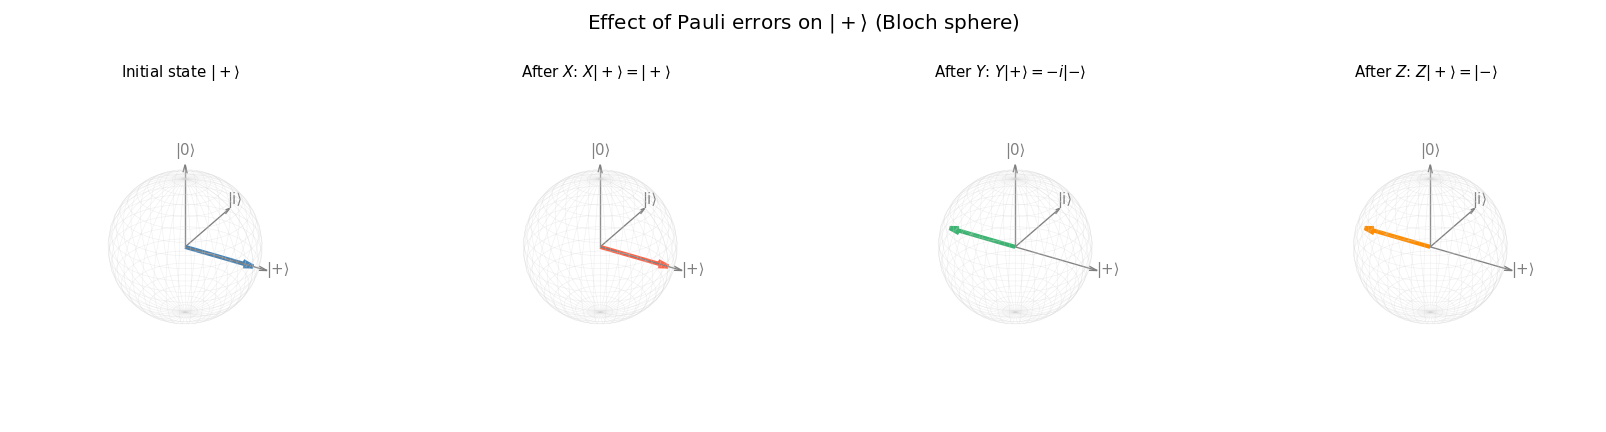

In [8]:
# ── Pauli matrices ──────────────────────────────────────────────────────────
I_m = np.eye(2, dtype=complex)
X_m = np.array([[0, 1], [1, 0]], dtype=complex)
Y_m = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z_m = np.array([[1, 0], [0, -1]], dtype=complex)

paulis = {"I": I_m, "X": X_m, "Y": Y_m, "Z": Z_m}

# Verify they form an orthonormal basis under HS inner product
print("Hilbert–Schmidt inner products <σi, σj> = Tr(σi† σj)/2:")
print("(Should be 1 on diagonal, 0 off-diagonal)\n")
labels = ["I", "X", "Y", "Z"]
table = np.zeros((4, 4))
for i, a in enumerate(labels):
    for j, b in enumerate(labels):
        table[i, j] = np.real(np.trace(paulis[a].conj().T @ paulis[b]) / 2)
print(np.array2string(table, formatter={'float_kind': lambda x: f"{x:5.1f}"}))


# ── Bloch sphere helper ─────────────────────────────────────────────────────
def bloch_vector(rho: np.ndarray) -> tuple:
    """Return (rx, ry, rz) Bloch vector for a 2x2 density matrix."""
    rx = np.real(np.trace(X_m @ rho))
    ry = np.real(np.trace(Y_m @ rho))
    rz = np.real(np.trace(Z_m @ rho))
    return rx, ry, rz


def plot_bloch_sphere(ax, vectors: list, colors: list, labels: list):
    """Plot one or more Bloch vectors on a 3D sphere."""
    # Draw sphere wireframe
    u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
    xs = np.cos(u)*np.sin(v)
    ys = np.sin(u)*np.sin(v)
    zs = np.cos(v)
    ax.plot_wireframe(xs, ys, zs, color='lightgray', linewidth=0.3, alpha=0.4)

    # Axes
    for d, lbl in zip([[1,0,0],[0,1,0],[0,0,1]], ['|+⟩','|i⟩','|0⟩']):
        ax.quiver(0,0,0, *d, length=1.2, color='gray', linewidth=0.8, arrow_length_ratio=0.1)
        ax.text(d[0]*1.35, d[1]*1.35, d[2]*1.35, lbl, ha='center', fontsize=9, color='gray')

    # Vectors
    for (rx, ry, rz), c, lbl in zip(vectors, colors, labels):
        ax.quiver(0,0,0, rx, ry, rz, length=1.0, normalize=False,
                  color=c, linewidth=2.5, arrow_length_ratio=0.15)
        ax.text(rx*1.15, ry*1.15, rz*1.15, lbl, color=c, fontsize=10, fontweight='bold')

    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_zlim(-1.3, 1.3)
    ax.set_box_aspect([1,1,1])
    ax.axis('off')


# ── Quick demo: Pauli actions on |+⟩ ────────────────────────────────────────
psi = np.array([1, 1], dtype=complex) / np.sqrt(2)  # |+⟩
rho = np.outer(psi, psi.conj())

fig = plt.figure(figsize=(14, 3.5))
titles = ["Initial state $|+\\rangle$",
          "After $X$: $X|+\\rangle = |+\\rangle$",
          "After $Y$: $Y|{+}\\rangle = -i|{-}\\rangle$",
          "After $Z$: $Z|+\\rangle = |{-}\\rangle$"]
error_ops = [I_m, X_m, Y_m, Z_m]
colors_list = ['steelblue', 'tomato', 'mediumseagreen', 'darkorange']

for idx, (E, title, col) in enumerate(zip(error_ops, titles, colors_list)):
    ax = fig.add_subplot(1, 4, idx+1, projection='3d')
    rho_e = E @ rho @ E.conj().T
    bv = bloch_vector(rho_e)
    plot_bloch_sphere(ax, [bv], [col], [''])
    ax.set_title(title, fontsize=9, pad=4)

plt.suptitle("Effect of Pauli errors on $|+\\rangle$ (Bloch sphere)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 1.3 Bit-Flip Errors ($X$ Errors)

### 1.3.1 Definition

A **bit-flip error** is the quantum analogue of a classical bit error. It is described
by the Pauli $X$ operator acting on a single qubit:

$$X = \begin{pmatrix}0 & 1 \\ 1 & 0\end{pmatrix}, \qquad X|0\rangle = |1\rangle, \quad X|1\rangle = |0\rangle$$

On a general superposition:

$$X(\alpha|0\rangle + \beta|1\rangle) = \alpha|1\rangle + \beta|0\rangle = \beta|0\rangle + \alpha|1\rangle$$

The amplitudes are **swapped**. The qubit still has a well-defined state, but $|0\rangle$
and $|1\rangle$ have exchanged roles.

### 1.3.2 Bloch sphere picture

The $X$ operator is a $\pi$-rotation about the $x$-axis of the Bloch sphere:

$$R_X(\pi) = e^{-i\pi X/2} = -iX$$

In Bloch vector components $(r_x, r_y, r_z)$, a bit-flip maps:

$$\vec{r} = (r_x, r_y, r_z) \;\xrightarrow{X}\; (r_x, -r_y, -r_z)$$

The $x$-component is preserved; $y$ and $z$ are negated. Equivalently, the state is
reflected through the $xz$-plane and then through the $xy$-plane.

### 1.3.3 Probabilistic bit-flip channel

A real physical channel rarely applies $X$ with certainty. More commonly, $X$ is
applied with probability $p$ and nothing happens with probability $1-p$. This is the
**bit-flip channel** $\mathcal{E}_{\text{bf}}$:

$$\mathcal{E}_{\text{bf}}(\rho) = (1-p)\,I\rho I + p\,X\rho X$$

**Kraus operators:**

$$K_0 = \sqrt{1-p}\; I, \qquad K_1 = \sqrt{p}\; X$$

**Verification:** $K_0^\dagger K_0 + K_1^\dagger K_1 = (1-p)I + pI = I$ ✓

**Effect on density matrix** for $\rho = \begin{pmatrix}\rho_{00} & \rho_{01} \\ \rho_{10} & \rho_{11}\end{pmatrix}$:

$$\mathcal{E}_{\text{bf}}(\rho)
= (1-p)\begin{pmatrix}\rho_{00} & \rho_{01} \\ \rho_{10} & \rho_{11}\end{pmatrix}
+ p\begin{pmatrix}\rho_{11} & \rho_{10} \\ \rho_{01} & \rho_{00}\end{pmatrix}
= \begin{pmatrix}(1-p)\rho_{00}+p\rho_{11} & (1-2p)\rho_{01} \\ (1-2p)\rho_{10} & (1-p)\rho_{11}+p\rho_{00}\end{pmatrix}$$

**Bloch vector action:**

$$r_x \to r_x, \quad r_y \to (1-2p)\,r_y, \quad r_z \to (1-2p)\,r_z$$

The Bloch sphere is **squeezed** toward the $x$-axis. At $p=0.5$, all information is
lost (the Bloch vector collapses to the origin along $y$ and $z$).

### 1.3.4 Connection to classical bit-flip codes

The 3-qubit repetition code (Chapter 2, Section 2.3) corrects a single bit-flip by
encoding:

$$|0\rangle_L = |000\rangle, \qquad |1\rangle_L = |111\rangle$$

This does *not* clone the qubit. The logical state
$|\psi\rangle_L = \alpha|000\rangle + \beta|111\rangle$ is a single entangled
state of three physical qubits in which $\alpha$ and $\beta$ cannot be read out
from any single qubit.

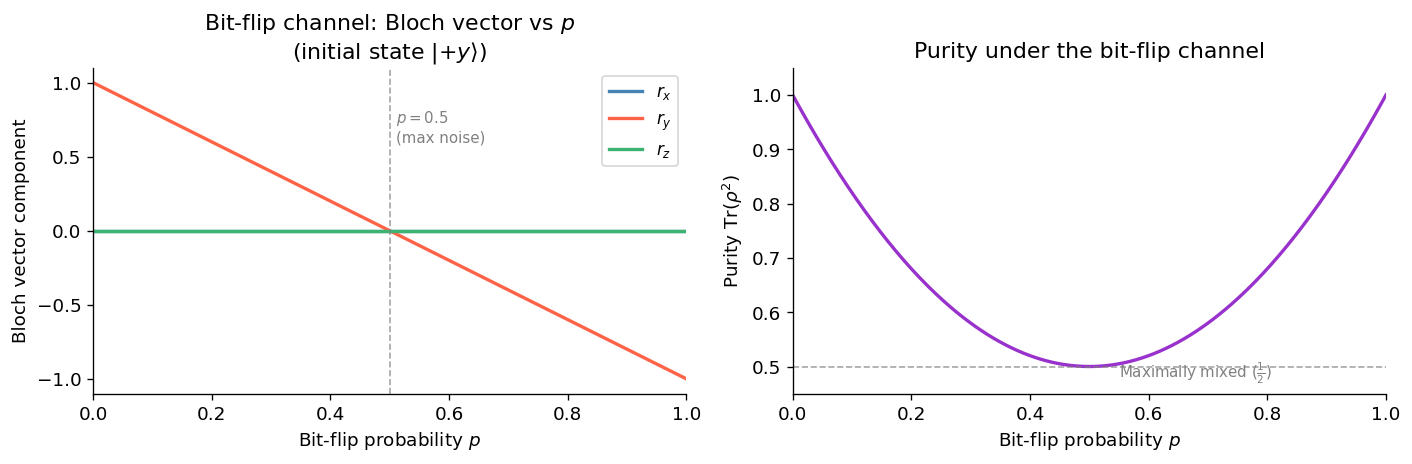

Observation: r_x is unchanged; r_y and r_z shrink as (1-2p).
At p=0.5 the state is maximally mixed in the y-z plane.

── Qiskit demonstration: 3-qubit bit-flip injection ──
     ┌───┐ ░       ░ ┌─┐      
q_0: ┤ H ├─░───────░─┤M├──────
     └───┘ ░ ┌───┐ ░ └╥┘┌─┐   
q_1: ──────░─┤ X ├─░──╫─┤M├───
           ░ └───┘ ░  ║ └╥┘┌─┐
q_2: ──────░───────░──╫──╫─┤M├
           ░       ░  ║  ║ └╥┘
c: 3/═════════════════╩══╩══╩═
                      0  1  2 

Measurement counts (should be mostly '010' due to X error on q1):
  010: 516
  011: 508


In [9]:
# ── Bit-flip channel: Kraus representation ──────────────────────────────────
def bit_flip_channel(rho: np.ndarray, p: float) -> np.ndarray:
    """Apply the bit-flip channel with error probability p."""
    K0 = np.sqrt(1 - p) * I_m
    K1 = np.sqrt(p) * X_m
    return K0 @ rho @ K0.conj().T + K1 @ rho @ K1.conj().T


# ── Visualize Bloch vector contraction as p increases ───────────────────────
# Initial state: |+y⟩ = (|0⟩ + i|1⟩)/√2  →  Bloch vector (0, 1, 0)
psi_y = np.array([1, 1j]) / np.sqrt(2)
rho0 = np.outer(psi_y, psi_y.conj())

p_vals = np.linspace(0, 1, 300)
rx_list, ry_list, rz_list = [], [], []

for p in p_vals:
    rho_p = bit_flip_channel(rho0, p)
    rx, ry, rz = bloch_vector(rho_p)
    rx_list.append(rx); ry_list.append(ry); rz_list.append(rz)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Bloch vector components vs p
ax = axes[0]
ax.plot(p_vals, rx_list, label='$r_x$', color='steelblue', linewidth=2)
ax.plot(p_vals, ry_list, label='$r_y$', color='tomato', linewidth=2)
ax.plot(p_vals, rz_list, label='$r_z$', color='mediumseagreen', linewidth=2)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(0.51, 0.6, '$p=0.5$\n(max noise)', fontsize=9, color='gray')
ax.set_xlabel('Bit-flip probability $p$')
ax.set_ylabel('Bloch vector component')
ax.set_title('Bit-flip channel: Bloch vector vs $p$\n(initial state $|{+y}\\rangle$)')
ax.legend(fontsize=10)
ax.set_xlim(0, 1)

# Right: Purity Tr(ρ²) vs p
purity = [np.real(np.trace(bit_flip_channel(rho0, p) @ bit_flip_channel(rho0, p)))
          for p in p_vals]
ax2 = axes[1]
ax2.plot(p_vals, purity, color='darkorchid', linewidth=2)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.text(0.55, 0.48, 'Maximally mixed ($\\frac{1}{2}$)', fontsize=9, color='gray')
ax2.set_xlabel('Bit-flip probability $p$')
ax2.set_ylabel(r'Purity $\mathrm{Tr}(\rho^2)$')
ax2.set_title('Purity under the bit-flip channel')
ax2.set_xlim(0, 1); ax2.set_ylim(0.45, 1.05)

plt.tight_layout()
plt.show()
print("Observation: r_x is unchanged; r_y and r_z shrink as (1-2p).")
print("At p=0.5 the state is maximally mixed in the y-z plane.")


# ── Qiskit: inject and detect a bit-flip error ───────────────────────────────
print("\n── Qiskit demonstration: 3-qubit bit-flip injection ──")
qc = QuantumCircuit(3, 3)
qc.h(0)                 # Prepare |+⟩ on qubit 0
qc.barrier()
qc.x(1)                 # Inject X error on qubit 1
qc.barrier()
qc.measure([0, 1, 2], [0, 1, 2])

print(qc.draw(output='text'))

sim = AerSimulator()
result = sim.run(transpile(qc, sim), shots=1024).result()
counts = result.get_counts()
print("\nMeasurement counts (should be mostly '010' due to X error on q1):")
for k, v in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v}")

## 1.4 Phase-Flip Errors ($Z$ Errors)

Phase-flip errors are **uniquely quantum** — they have no classical analogue.
A classical bit is either 0 or 1; there is no concept of "relative phase" between them.
In quantum computing, the relative phase between $|0\rangle$ and $|1\rangle$ carries
physical information that can be corrupted independently of the bit values.

### 1.4.1 Definition

The phase-flip error is described by the Pauli $Z$ operator:

$$Z = \begin{pmatrix}1 & 0 \\ 0 & -1\end{pmatrix}, \qquad Z|0\rangle = |0\rangle, \quad Z|1\rangle = -|1\rangle$$

On a general superposition:

$$Z(\alpha|0\rangle + \beta|1\rangle) = \alpha|0\rangle - \beta|1\rangle$$

The populations $|\alpha|^2$, $|\beta|^2$ are **unchanged** — a measurement in the
computational basis cannot detect this error. The sign change is **invisible to $Z$-basis
measurements**, which is why phase-flip errors are so dangerous and so often overlooked.

### 1.4.2 Bloch sphere picture

The $Z$ operator is a $\pi$-rotation about the $z$-axis:

$$R_Z(\pi) = e^{-i\pi Z/2} = -iZ$$

In Bloch vector components:

$$\vec{r} = (r_x, r_y, r_z) \;\xrightarrow{Z}\; (-r_x, -r_y, r_z)$$

The $z$-component is preserved; $x$ and $y$ are negated. The state is
reflected through the $yz$-plane and then through the $xz$-plane.

> **Intuition:** A qubit in $|0\rangle$ or $|1\rangle$ (the $Z$ eigenstates) is
> completely unaffected by a $Z$ error. Only superpositions are damaged. This is
> why error correction schemes must protect phases, not just bit values.

### 1.4.3 Phase-flip channel

Analogously to the bit-flip channel, the **phase-flip channel** applies $Z$ with
probability $p$:

$$\mathcal{E}_{\text{pf}}(\rho) = (1-p)\,I\rho I + p\,Z\rho Z$$

**Kraus operators:**

$$K_0 = \sqrt{1-p}\; I, \qquad K_1 = \sqrt{p}\; Z$$

**Effect on density matrix:**

$$\mathcal{E}_{\text{pf}}(\rho)
= \begin{pmatrix}\rho_{00} & (1-2p)\rho_{01} \\ (1-2p)\rho_{10} & \rho_{11}\end{pmatrix}$$

The diagonal elements (populations) are untouched. The off-diagonal elements
(coherences) are attenuated by factor $(1-2p)$.

**Bloch vector action:**

$$r_x \to (1-2p)\,r_x, \quad r_y \to (1-2p)\,r_y, \quad r_z \to r_z$$

The Bloch sphere is squeezed toward the $z$-axis.

### 1.4.4 Relationship between bit-flip and phase-flip codes

The phase-flip code is obtained by applying Hadamard gates $H$ to transform to the
$X$-basis:

$$H = \frac{1}{\sqrt{2}}\begin{pmatrix}1 & 1 \\ 1 & -1\end{pmatrix},
\qquad H|0\rangle = |+\rangle, \quad H|1\rangle = |-\rangle$$

In the $X$-basis, a $Z$ error acts as a bit flip:

$$HZH = X$$

This means a 3-qubit repetition code in the $X$-basis:

$$|0\rangle_L = |{+}{+}{+}\rangle, \qquad |1\rangle_L = |{-}{-}{-}\rangle$$

corrects single phase-flip errors. Shor's 9-qubit code (Chapter 2, Section 2.4)
concatenates bit-flip and phase-flip codes to protect against both simultaneously.

=== Z error is invisible to Z-basis measurement ===
|+⟩ probability of measuring |0⟩: 0.500
|-⟩ probability of measuring |0⟩: 0.500
→ Z-basis measurement cannot distinguish |+⟩ from |-⟩

|+⟩ probability of measuring |+⟩ (X-basis): 1.000
|-⟩ probability of measuring |+⟩ (X-basis): 0.000
→ X-basis measurement immediately reveals the phase flip



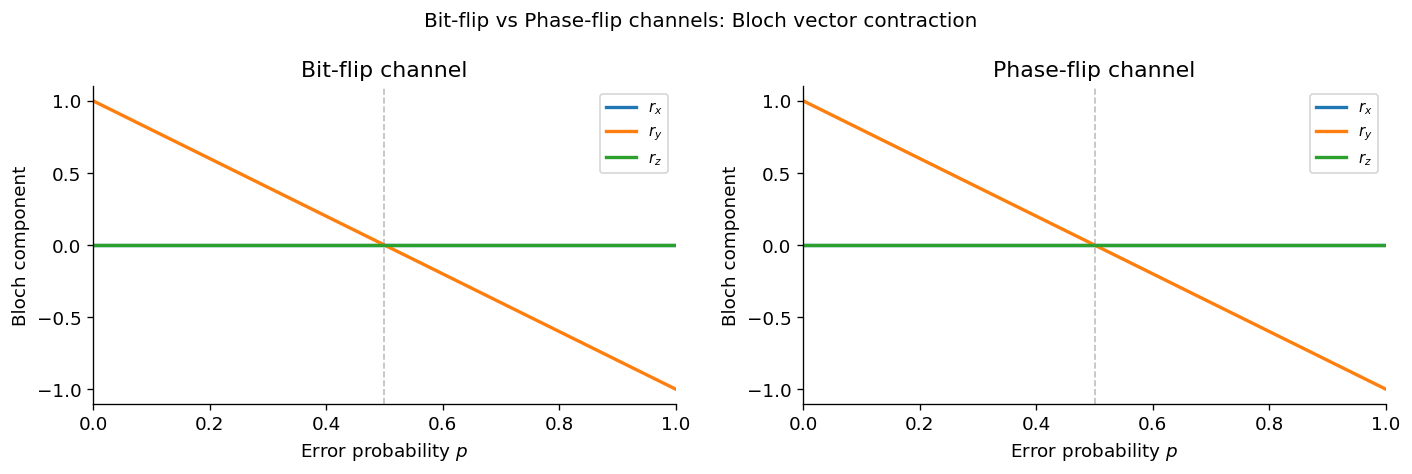

── Qiskit: Z-basis measurement on |+⟩ vs |-⟩ ──
  No error (|+⟩): {'1': 1059, '0': 989}
  Z error  (|-⟩): {'0': 1026, '1': 1022}

Conclusion: Z-basis measurement sees 50/50 in both cases.
Phase errors require X-basis (Hadamard + measurement) to detect.


In [10]:
def phase_flip_channel(rho: np.ndarray, p: float) -> np.ndarray:
    K0 = np.sqrt(1 - p) * I_m
    K1 = np.sqrt(p) * Z_m
    return K0 @ rho @ K0.conj().T + K1 @ rho @ K1.conj().T


# ── Show that Z error is invisible to computational-basis measurement ────────
psi_plus = np.array([1, 1]) / np.sqrt(2)   # |+⟩
rho_plus = np.outer(psi_plus, psi_plus.conj())

rho_after_Z = Z_m @ rho_plus @ Z_m.conj().T   # = |-⟩⟨-|

print("=== Z error is invisible to Z-basis measurement ===")
print(f"|+⟩ probability of measuring |0⟩: {np.real(rho_plus[0,0]):.3f}")
print(f"|-⟩ probability of measuring |0⟩: {np.real(rho_after_Z[0,0]):.3f}")
print("→ Z-basis measurement cannot distinguish |+⟩ from |-⟩\n")
print(f"|+⟩ probability of measuring |+⟩ (X-basis): "
      f"{np.real(np.trace(rho_plus @ rho_plus)):.3f}")
print(f"|-⟩ probability of measuring |+⟩ (X-basis): "
      f"{np.real(np.trace(rho_after_Z @ rho_plus)):.3f}")
print("→ X-basis measurement immediately reveals the phase flip\n")


# ── Side-by-side: bit-flip vs phase-flip channel on Bloch sphere ─────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

p_vals2 = np.linspace(0, 1, 200)
rho_test = np.outer(np.array([1, 1j])/np.sqrt(2), np.array([1, -1j])/np.sqrt(2))

for ax, ch_fn, title, color in zip(
    axes,
    [bit_flip_channel, phase_flip_channel],
    ["Bit-flip channel", "Phase-flip channel"],
    ['tomato', 'steelblue']
):
    bvx, bvy, bvz = [], [], []
    for p in p_vals2:
        rx, ry, rz = bloch_vector(ch_fn(rho_test, p))
        bvx.append(rx); bvy.append(ry); bvz.append(rz)

    ax.plot(p_vals2, bvx, label='$r_x$', linewidth=2)
    ax.plot(p_vals2, bvy, label='$r_y$', linewidth=2)
    ax.plot(p_vals2, bvz, label='$r_z$', linewidth=2)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Error probability $p$')
    ax.set_ylabel('Bloch component')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)

plt.suptitle("Bit-flip vs Phase-flip channels: Bloch vector contraction",
             fontsize=12)
plt.tight_layout()
plt.show()


# ── Qiskit: Z-basis measurement cannot detect a phase flip ───────────────────
print("── Qiskit: Z-basis measurement on |+⟩ vs |-⟩ ──")
for label, gate in [("No error (|+⟩)", False), ("Z error  (|-⟩)", True)]:
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    if gate:
        qc.z(0)
    qc.measure(0, 0)
    result = sim.run(transpile(qc, sim), shots=2048).result()
    counts = result.get_counts()
    print(f"  {label}: {counts}")
print("\nConclusion: Z-basis measurement sees 50/50 in both cases.")
print("Phase errors require X-basis (Hadamard + measurement) to detect.")

## 1.5 Bit-Phase Flip Errors ($Y$ Errors) and the Depolarizing Channel

### 1.5.1 The $Y$ error

The Pauli $Y$ operator combines a bit flip and a phase flip:

$$Y = iXZ = \begin{pmatrix}0 & -i \\ i & 0\end{pmatrix},
\qquad Y|0\rangle = i|1\rangle, \quad Y|1\rangle = -i|0\rangle$$

On a general state:

$$Y(\alpha|0\rangle + \beta|1\rangle) = i\alpha|1\rangle - i\beta|0\rangle
= -i(\beta|0\rangle - \alpha|1\rangle)$$

Both the bit value *and* the phase have flipped. The global phase $-i$ is unobservable,
so the distinguishing effect is: amplitudes swapped **and** sign changed on one term.

**Bloch sphere:** $Y$ is a $\pi$-rotation about the $y$-axis:

$$\vec{r} = (r_x, r_y, r_z) \;\xrightarrow{Y}\; (-r_x, r_y, -r_z)$$

### 1.5.2 The depolarizing channel

The **depolarizing channel** $\mathcal{E}_{\text{dep}}$ is the most symmetric noise model.
With probability $p$ the qubit is replaced by the maximally mixed state $I/2$;
with probability $1-p$ it is unchanged:

$$\mathcal{E}_{\text{dep}}(\rho) = (1-p)\,\rho + \frac{p}{4}\,(I\rho I + X\rho X + Y\rho Y + Z\rho Z)$$

Since $I\rho I + X\rho X + Y\rho Y + Z\rho Z = 2I$ (a well-known Pauli identity), this simplifies to:

$$\mathcal{E}_{\text{dep}}(\rho) = \left(1 - \frac{3p}{4}\right)\rho + \frac{p}{4}\,I$$

> **Note on convention:** Some references write the depolarizing channel as
> $\mathcal{E}(\rho) = (1-p)\rho + p\frac{I}{2}$, which corresponds to $p_{\text{here}} = 4p/3$.
> Always check the convention when comparing error rates.

**Kraus operators** (symmetric form):

$$K_0 = \sqrt{1-\frac{3p}{4}}\; I, \quad
K_1 = \frac{\sqrt{p}}{2} X, \quad
K_2 = \frac{\sqrt{p}}{2} Y, \quad
K_3 = \frac{\sqrt{p}}{2} Z$$

**Bloch vector action** — all components contract uniformly:

$$\vec{r} \;\to\; \left(1 - p\right)\vec{r}$$

The Bloch sphere **shrinks isotropically**. At $p=1$, the state is the maximally mixed
state $I/2$ regardless of the input. This is why depolarizing noise is considered the
"worst" simple error model — it erases all directional coherence.

### 1.5.3 Physical realization of depolarizing noise

The depolarizing channel is often used as a simplified model for:

- **Two-qubit gate errors** in superconducting systems (typical rate: $10^{-3}$)
- **Crosstalk** between neighboring qubits
- **High-temperature environments** where all three Pauli errors are roughly equally likely

In practice, real noise is asymmetric: $Z$ errors dominate in most platforms
(see Section 1.8), so the depolarizing model overestimates $X$ and $Y$ error rates.

### 1.5.4 Summary: all single-qubit Pauli error channels

| Channel | Kraus operators | Bloch sphere effect |
|---|---|---|
| Bit-flip | $\sqrt{1-p}\,I,\; \sqrt{p}\,X$ | Squeezes toward $x$-axis |
| Phase-flip | $\sqrt{1-p}\,I,\; \sqrt{p}\,Z$ | Squeezes toward $z$-axis |
| Bit-phase-flip | $\sqrt{1-p}\,I,\; \sqrt{p}\,Y$ | Squeezes toward $y$-axis |
| Depolarizing | $\sqrt{1-3p/4}\,I,\; \frac{\sqrt{p}}{2}\{X,Y,Z\}$ | Uniform contraction |

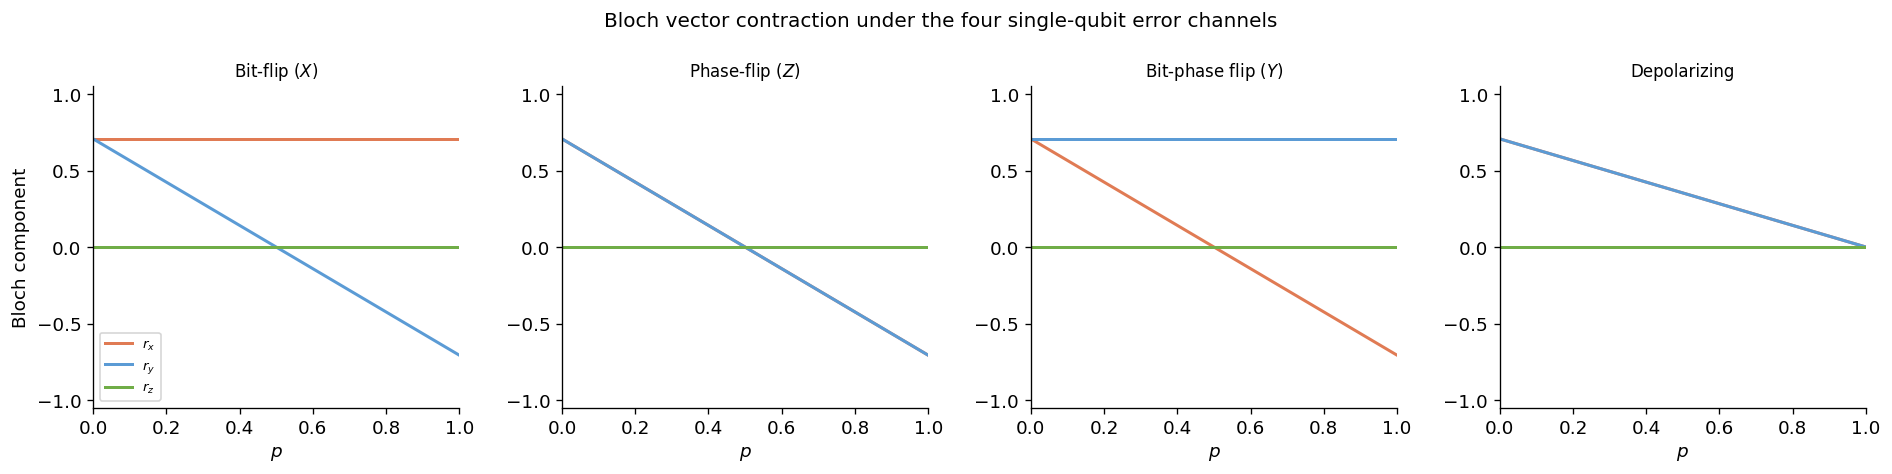

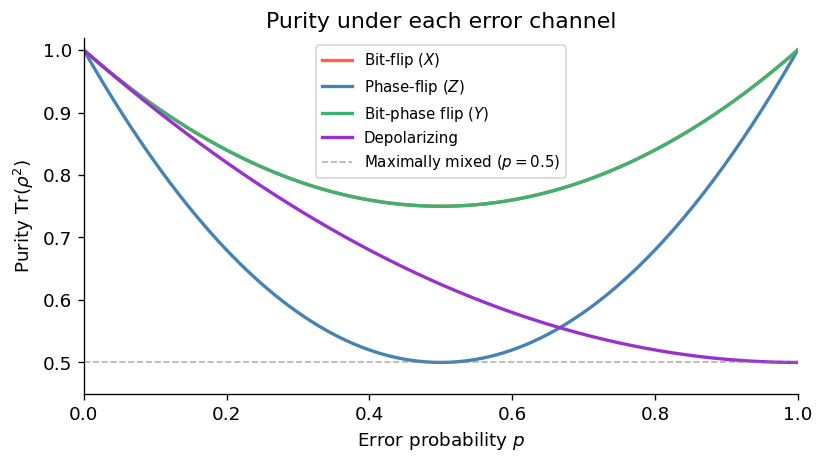

Key observation:
  Bit/phase/Y channels reach minimum purity at p=0.5, then recover symmetrically.
  Depolarizing channel reaches minimum purity at p=1 (maximally mixed).


In [11]:
def depolarizing_channel(rho: np.ndarray, p: float) -> np.ndarray:
    """Depolarizing channel: (1-p)ρ + p*I/2.
    Here p is the total depolarization probability."""
    return (1 - p) * rho + p * np.eye(2) / 2


def y_error_channel(rho: np.ndarray, p: float) -> np.ndarray:
    K0 = np.sqrt(1 - p) * I_m
    K1 = np.sqrt(p) * Y_m
    return K0 @ rho @ K0.conj().T + K1 @ rho @ K1.conj().T


# ── Bloch sphere: four channels side by side ─────────────────────────────────
channels = {
    "Bit-flip ($X$)": bit_flip_channel,
    "Phase-flip ($Z$)": phase_flip_channel,
    "Bit-phase flip ($Y$)": y_error_channel,
    "Depolarizing": depolarizing_channel,
}

# Initial state: arbitrary state on equator tilted at 45°
theta, phi = np.pi/2, np.pi/4
psi_init = np.array([np.cos(theta/2),
                     np.exp(1j*phi)*np.sin(theta/2)], dtype=complex)
rho_init = np.outer(psi_init, psi_init.conj())
r_init = bloch_vector(rho_init)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors_ch = ['tomato', 'steelblue', 'mediumseagreen', 'darkorchid']

for ax, (name, ch), col in zip(axes, channels.items(), colors_ch):
    p_vals3 = np.linspace(0, 1, 200)
    bvx, bvy, bvz = [], [], []
    for p in p_vals3:
        rx, ry, rz = bloch_vector(ch(rho_init, p))
        bvx.append(rx); bvy.append(ry); bvz.append(rz)

    ax.plot(p_vals3, bvx, label='$r_x$', color='#e07b54', linewidth=1.8)
    ax.plot(p_vals3, bvy, label='$r_y$', color='#5b9bd5', linewidth=1.8)
    ax.plot(p_vals3, bvz, label='$r_z$', color='#70ad47', linewidth=1.8)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('$p$')
    ax.set_xlim(0, 1)
    ax.set_ylim(-1.05, 1.05)
    if ax == axes[0]:
        ax.set_ylabel('Bloch component')
        ax.legend(fontsize=8)

plt.suptitle("Bloch vector contraction under the four single-qubit error channels",
             fontsize=12)
plt.tight_layout()
plt.show()

# ── Purity comparison ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
p_arr = np.linspace(0, 1, 300)
for (name, ch), col in zip(channels.items(), colors_ch):
    purity_arr = [np.real(np.trace(ch(rho_init, p) @ ch(rho_init, p)))
                  for p in p_arr]
    ax.plot(p_arr, purity_arr, label=name, color=col, linewidth=2)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6,
           label='Maximally mixed ($p=0.5$)')
ax.set_xlabel('Error probability $p$')
ax.set_ylabel(r'Purity $\mathrm{Tr}(\rho^2)$')
ax.set_title('Purity under each error channel')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0.45, 1.02)
plt.tight_layout()
plt.show()

print("Key observation:")
print("  Bit/phase/Y channels reach minimum purity at p=0.5, then recover symmetrically.")
print("  Depolarizing channel reaches minimum purity at p=1 (maximally mixed).")

## 1.6 Decoherence — $T_1$, $T_2$, and Open Quantum Systems

The error models in Sections 1.3–1.5 are **discrete** — they represent instantaneous
application of Pauli operators. Real qubits undergo **continuous** decay and dephasing
due to coupling with their environment. These processes are described by the
**Lindblad master equation** and characterized by the timescales $T_1$ and $T_2$.

### 1.6.1 Open quantum systems and the density matrix

A qubit coupled to an environment cannot be described by a pure state vector
$|\psi\rangle$. Instead, we use the **density matrix** $\rho$ — a positive
semidefinite, Hermitian operator with $\text{Tr}(\rho) = 1$.

For a single qubit, the density matrix in the $\{|0\rangle, |1\rangle\}$ basis is:

$$\rho = \begin{pmatrix}\rho_{00} & \rho_{01} \\ \rho_{10} & \rho_{11}\end{pmatrix}$$

where:
- $\rho_{00}$, $\rho_{11}$: **populations** (probability of being in $|0\rangle$, $|1\rangle$)
- $\rho_{01} = \rho_{10}^*$: **coherences** (off-diagonal, carry phase information)

The Bloch vector is $\vec{r} = (\text{Tr}(X\rho),\, \text{Tr}(Y\rho),\, \text{Tr}(Z\rho))$,
so $\rho = \frac{1}{2}(I + \vec{r}\cdot\vec{\sigma})$.

### 1.6.2 The Lindblad master equation

The most general **Markovian** (memoryless) time evolution of a density matrix is
given by the **Gorini–Kossakowski–Sudarshan–Lindblad (GKSL) equation** [5]:

$$\frac{d\rho}{dt} = -\frac{i}{\hbar}[H, \rho]
+ \sum_k \gamma_k \left(L_k \rho L_k^\dagger
- \frac{1}{2}L_k^\dagger L_k \rho
- \frac{1}{2}\rho L_k^\dagger L_k\right)$$

where:
- $H$ is the system Hamiltonian (coherent evolution)
- $L_k$ are the **Lindblad (jump) operators** describing each dissipative process
- $\gamma_k \geq 0$ are the corresponding **decay rates**
- The term $\mathcal{D}[L_k]\rho \equiv L_k\rho L_k^\dagger - \frac{1}{2}\{L_k^\dagger L_k, \rho\}$ is the **dissipator**

The Lindblad equation is the most general form that guarantees:
1. $\rho(t)$ remains positive semidefinite ✓
2. $\text{Tr}(\rho(t)) = 1$ for all $t$ ✓
3. The evolution is Markovian (semigroup property) ✓

### 1.6.3 Amplitude damping ($T_1$ process)

**Physical origin:** Energy relaxation — the qubit decays from excited state $|1\rangle$
to ground state $|0\rangle$, releasing energy to the environment (e.g., a photon in
a cavity, a phonon in a crystal).

**Lindblad operator:**

$$L_1 = \sigma_- = |0\rangle\langle 1| = \begin{pmatrix}0 & 1 \\ 0 & 0\end{pmatrix},
\quad \gamma_1 = \frac{1}{T_1}$$

**Master equation (no $H$ term):**

$$\dot{\rho}_{00} = +\frac{\rho_{11}}{T_1}, \qquad
\dot{\rho}_{11} = -\frac{\rho_{11}}{T_1}, \qquad
\dot{\rho}_{01} = -\frac{\rho_{01}}{2T_1}$$

**Solution:**

$$\rho_{11}(t) = \rho_{11}(0)\,e^{-t/T_1}$$

$$\rho_{01}(t) = \rho_{01}(0)\,e^{-t/(2T_1)}$$

$$\rho_{00}(t) = 1 - \rho_{11}(t)$$

The excited state population decays exponentially with time constant $T_1$.
The coherences decay with time constant $2T_1$.

**Kraus representation** (discrete version at time $t$, with $p = 1 - e^{-t/T_1}$):

$$K_0 = \begin{pmatrix}1 & 0 \\ 0 & \sqrt{1-p}\end{pmatrix}, \qquad
K_1 = \begin{pmatrix}0 & \sqrt{p} \\ 0 & 0\end{pmatrix}$$

### 1.6.4 Pure dephasing ($T_\phi$ process) and $T_2$

**Physical origin:** Random phase kicks — fluctuating fields (charge noise, flux noise,
phonons) cause the qubit's transition frequency to fluctuate, randomizing the relative
phase between $|0\rangle$ and $|1\rangle$.

**Lindblad operator:**

$$L_2 = \frac{1}{\sqrt{2}} Z = \frac{1}{\sqrt{2}}\begin{pmatrix}1 & 0 \\ 0 & -1\end{pmatrix},
\quad \gamma_2 = \frac{1}{T_\phi}$$

**Master equation:**

$$\dot{\rho}_{00} = \dot{\rho}_{11} = 0, \qquad
\dot{\rho}_{01} = -\frac{\rho_{01}}{T_\phi}$$

Populations are **conserved**; only coherences decay.

**Solution:**

$$\rho_{01}(t) = \rho_{01}(0)\,e^{-t/T_\phi}$$

**Combined $T_1$ and $T_2$:** When both amplitude damping and dephasing are present,
the total decoherence rate of off-diagonal elements is:

$$\frac{1}{T_2} = \frac{1}{2T_1} + \frac{1}{T_\phi}$$

This is the standard **Bloch equation** relation from NMR/quantum optics.
Note that $T_2 \leq 2T_1$ always; the $T_1$ process alone gives $T_2 = 2T_1$.

**Full combined Lindblad equation** ($H = 0$):

$$\frac{d\rho}{dt} = \frac{1}{T_1}\left(\sigma_-\rho\sigma_+ - \frac{1}{2}\sigma_+\sigma_-\rho
- \frac{1}{2}\rho\sigma_+\sigma_-\right)
+ \frac{1}{T_\phi}\left(Z\rho Z - \rho\right) \cdot \frac{1}{4} \cdot 4$$

or in Bloch vector form:

$$\dot{r}_x = -\frac{r_x}{T_2}, \qquad
\dot{r}_y = -\frac{r_y}{T_2}, \qquad
\dot{r}_z = -\frac{r_z - r_z^\infty}{T_1}$$

where $r_z^\infty = -1$ (ground state at zero temperature, $\rho_{11}^\infty = 0$).

**Solution (Bloch equations with ground-state equilibrium):**

$$r_x(t) = r_x(0)\,e^{-t/T_2}, \qquad
r_y(t) = r_y(0)\,e^{-t/T_2}, \qquad
r_z(t) = -1 + \bigl(r_z(0) + 1\bigr)\,e^{-t/T_1}$$

### 1.6.5 Typical $T_1$, $T_2$ values by platform

| Platform | $T_1$ | $T_2$ | $T_2 / T_1$ | Dominant limit |
|---|---|---|---|---|
| Superconducting (transmon) | 10–500 µs | 10–400 µs | ~0.5–1 | Charge/flux noise, TLS |
| Trapped ion ($^{171}$Yb$^+$) | $>1$ hour | ~1 s | ~1 | Magnetic field fluctuations |
| Neutral atom (Rydberg) | ~100 µs | ~1 ms | ~10 | Laser phase noise, atom loss |
| Silicon spin qubit | ~10 ms | ~1 ms | ~0.1 | Charge/nuclear spin noise |
| Photonic qubit | $\infty$ | $\infty$ | — | Photon loss (not T₁/T₂) |

*Table compiled from: Krantz et al., Appl. Phys. Rev. 2019; Bruzewicz et al., Appl. Phys. Rev. 2019.*

T1 = 1.00,  T_phi = 4.00,  T2 = 1.3333


/usr/local/lib/python3.12/dist-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


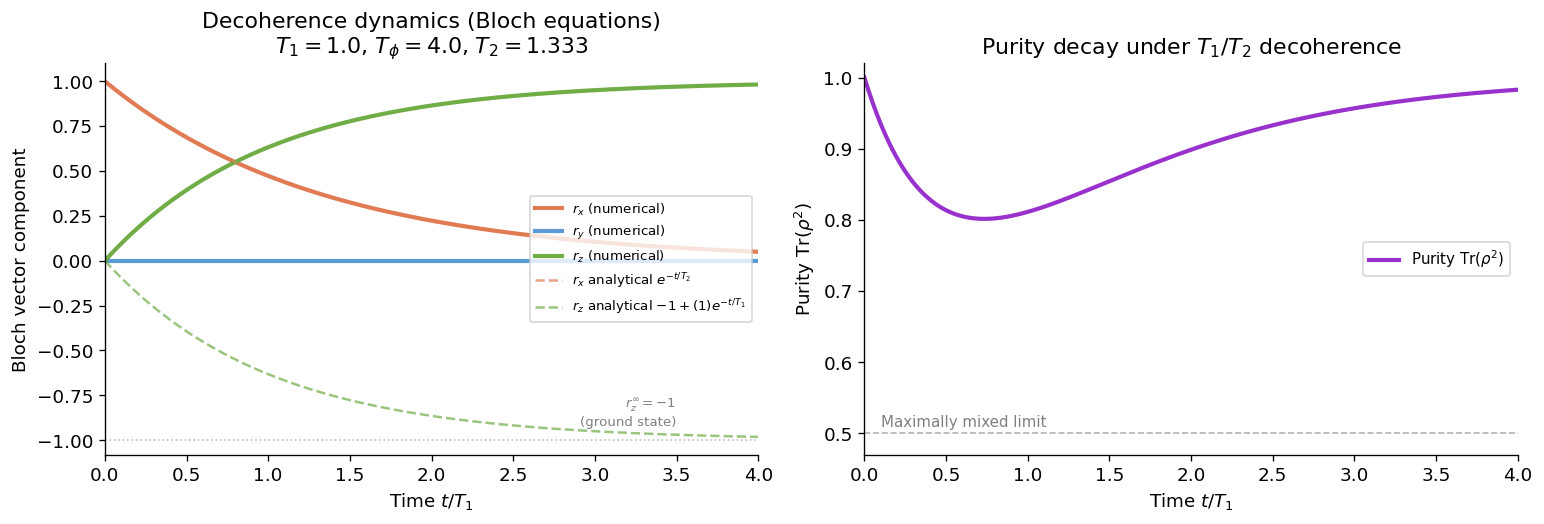

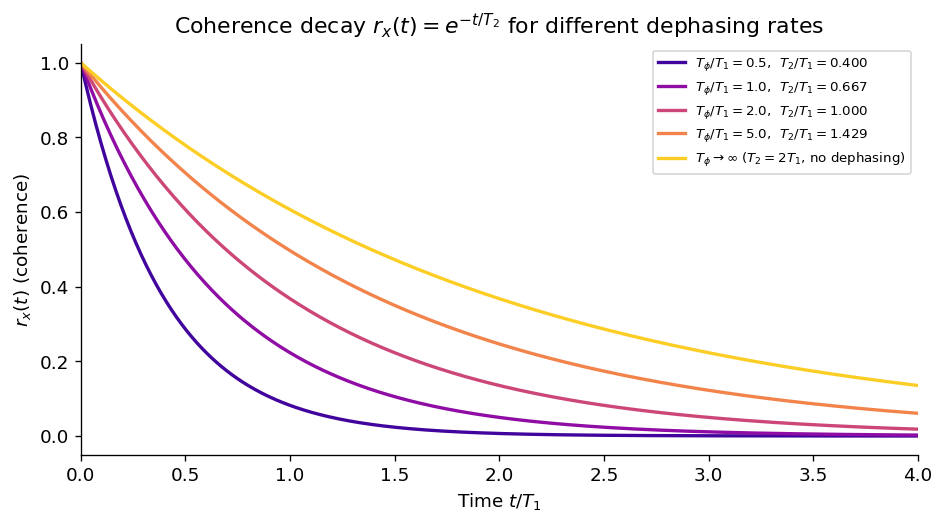


Key result: T2 ≤ 2T1 always. When T_phi → ∞, T2 → 2T1.
When dephasing dominates (T_phi ≪ T1), T2 → T_phi ≪ T1.


In [16]:
def lindblad_rhs(t, rho_flat, T1, T_phi):
    """
    Right-hand side of the Lindblad master equation.
    Includes amplitude damping (T1) and pure dephasing (T_phi).
    rho_flat: flattened 4-element complex vector [ρ00, ρ01, ρ10, ρ11]
    """
    rho = rho_flat.reshape(2, 2)

    # Amplitude damping: L = σ₋ = |0><1|, γ = 1/T1
    sigma_minus = np.array([[0, 1], [0, 0]], dtype=complex)
    sigma_plus  = sigma_minus.conj().T
    if T1 > 0:
        damp = (1/T1) * (
            sigma_minus @ rho @ sigma_plus
            - 0.5 * (sigma_plus @ sigma_minus @ rho)
            - 0.5 * (rho @ sigma_plus @ sigma_minus)
        )
    else:
        damp = np.zeros((2, 2), dtype=complex)

    # Pure dephasing: L = Z/√2, γ = 1/T_phi → rate = 2/T_phi
    if T_phi > 0:
        deph = (1 / (2 * T_phi)) * (
            Z_m @ rho @ Z_m
            - rho
        )
    else:
        deph = np.zeros((2, 2), dtype=complex)

    drho = damp + deph
    return drho.flatten()


def simulate_decoherence(rho0, T1, T_phi, t_end, n_points=500):
    """Simulate Lindblad evolution; return times and (rx, ry, rz, purity)."""
    t_span = (0, t_end)
    t_eval = np.linspace(0, t_end, n_points)

    sol = solve_ivp(
        lindblad_rhs,
        t_span,
        rho0.flatten(),
        args=(T1, T_phi),
        t_eval=t_eval,
        method='RK45',
        rtol=1e-9, atol=1e-12
    )

    rx_t, ry_t, rz_t, pur_t = [], [], [], []
    for rho_flat in sol.y.T:
        rho_t = rho_flat.reshape(2, 2)
        rx, ry, rz = bloch_vector(rho_t)
        rx_t.append(rx); ry_t.append(ry); rz_t.append(rz)
        pur_t.append(np.real(np.trace(rho_t @ rho_t)))

    return sol.t, np.array(rx_t), np.array(ry_t), np.array(rz_t), np.array(pur_t)


# ── Parameters ───────────────────────────────────────────────────────────────
T1    = 1.0    # normalized to 1 (everything in units of T1)
T_phi = 4.0    # T_phi = 4*T1  →  T2 = 1/(1/2T1 + 1/4T1) = 1/(3/4T1) = 4T1/3 ≈ 1.333

T2 = 1 / (1/(2*T1) + 1/T_phi)
print(f"T1 = {T1:.2f},  T_phi = {T_phi:.2f},  T2 = {T2:.4f}")

# Initial state: equatorial state |+x⟩ = (|0⟩+|1⟩)/√2
psi_eq = np.array([1, 1]) / np.sqrt(2)
rho_eq = np.outer(psi_eq, psi_eq.conj())

t, rx, ry, rz, purity = simulate_decoherence(rho_eq, T1, T_phi, t_end=4*T1)

# Analytical solutions
t_anal = np.linspace(0, 4*T1, 500)
rx_a = np.exp(-t_anal / T2)          # starts at 1 for |+x⟩
rz_a = -1 + (0 + 1) * np.exp(-t_anal / T1)  # starts at 0, goes to -1


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: Bloch components
ax1 = axes[0]
ax1.plot(t/T1, rx, color='#e07b54', linewidth=2.5, label='$r_x$ (numerical)')
ax1.plot(t/T1, ry, color='#5b9bd5', linewidth=2.5, label='$r_y$ (numerical)')
ax1.plot(t/T1, rz, color='#70ad47', linewidth=2.5, label='$r_z$ (numerical)')
ax1.plot(t_anal/T1, rx_a, '--', color='#e07b54', linewidth=1.5,
         alpha=0.7, label='$r_x$ analytical $e^{-t/T_2}$')
ax1.plot(t_anal/T1, rz_a, '--', color='#70ad47', linewidth=1.5,
         alpha=0.7, label='$r_z$ analytical $-1+(1)e^{-t/T_1}$')
ax1.set_xlabel('Time $t / T_1$')
ax1.set_ylabel('Bloch vector component')
ax1.set_title('Decoherence dynamics (Bloch equations)\n'
              f'$T_1={T1}$, $T_\\phi={T_phi}$, $T_2={T2:.3f}$')
ax1.legend(fontsize=8, loc='right')
ax1.set_xlim(0, 4)
ax1.axhline(-1, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.text(3.5, -0.92, '$r_z^\\infty = -1$\n(ground state)',
         fontsize=8, color='gray', ha='right')

# Right: Purity
ax2 = axes[1]
ax2.plot(t/T1, purity, color='darkorchid', linewidth=2.5, label='Purity $\\mathrm{Tr}(\\rho^2)$')
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax2.text(0.1, 0.51, 'Maximally mixed limit', fontsize=9, color='gray')
ax2.set_xlabel('Time $t / T_1$')
ax2.set_ylabel(r'Purity $\mathrm{Tr}(\rho^2)$')
ax2.set_title('Purity decay under $T_1$/$T_2$ decoherence')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 4); ax2.set_ylim(0.47, 1.02)

plt.tight_layout()
plt.show()


# ── Vary T_phi/T1 ratio ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
#t_arr = np.linspace(0, 4*T1, 500)
ratios = [0.5, 1.0, 2.0, 5.0, np.inf]  # T_phi / T1
colors_r = plt.cm.plasma(np.linspace(0.1, 0.9, len(ratios)))

for ratio, col in zip(ratios, colors_r):
    T_phi_r = ratio * T1 if ratio != np.inf else 1e12
    T2_r = 1 / (1/(2*T1) + 1/T_phi_r)
    _, rx_r, *_ = simulate_decoherence(rho_eq, T1, T_phi_r, t_end=4*T1)
    lbl = (f"$T_\\phi/T_1 = {ratio:.1f}$,  $T_2/T_1 = {T2_r/T1:.3f}$"
           if ratio != np.inf else
           f"$T_\\phi \\to \\infty$ ($T_2 = 2T_1$, no dephasing)")
    ax.plot(t/T1, rx_r, color=col, linewidth=2, label=lbl)

ax.set_xlabel('Time $t / T_1$')
ax.set_ylabel('$r_x(t)$ (coherence)')
ax.set_title('Coherence decay $r_x(t) = e^{-t/T_2}$ for different dephasing rates')
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(0, 4); ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print(f"\nKey result: T2 ≤ 2T1 always. When T_phi → ∞, T2 → 2T1.")
print(f"When dephasing dominates (T_phi ≪ T1), T2 → T_phi ≪ T1.")

Thermal relaxation error channel (Kraus operators):
  T1 = 100.0 µs,  T2 = 80.0 µs,  gate time = 50 ns
  Error probability ≈ t_gate/T1 = 5.00e-04 per gate

Fidelity of |+⟩ after N idle gates (thermal relaxation noise model):
    N idle |    Noisy F |    Ideal F
-----------------------------------
         0 |     0.9997 |     1.0000
        10 |     0.9966 |     1.0000
       100 |     0.9694 |     1.0000
       500 |     0.8656 |     1.0000
      1000 |     0.7675 |     1.0000


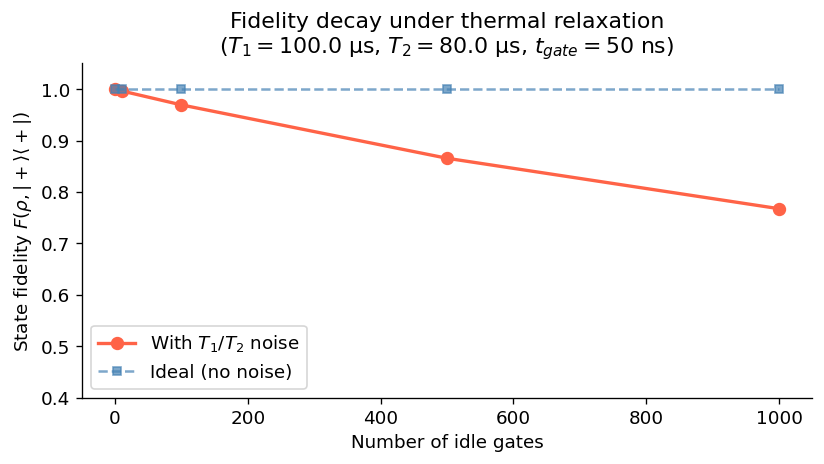

In [14]:
# ── Qiskit: simulate T1/T2 using thermal_relaxation_error ───────────────────
# Typical superconducting qubit parameters
T1_us  = 100.0   # microseconds
T2_us  =  80.0   # microseconds  (T2 < 2*T1 as required)
t_gate = 0.05    # gate time (50 ns)

# Build noise model
noise_model = NoiseModel()
t1_t2_error = thermal_relaxation_error(T1_us * 1e3,   # convert to ns
                                        T2_us * 1e3,
                                        t_gate * 1e3)
noise_model.add_all_qubit_quantum_error(t1_t2_error, ['h', 'x', 'z', 'rz', 'sx', 'id'])

print("Thermal relaxation error channel (Kraus operators):")
print(f"  T1 = {T1_us} µs,  T2 = {T2_us} µs,  gate time = {t_gate*1e3:.0f} ns")
print(f"  Error probability ≈ t_gate/T1 = {t_gate/T1_us:.2e} per gate\n")

# Run a circuit that prepares |+⟩ and idles for varying numbers of gates
n_idle_list = [0, 10, 100, 500, 1000]
fidelities_noisy = []
fidelities_ideal  = []

target_state = DensityMatrix(np.array([[0.5, 0.5], [0.5, 0.5]]))  # |+⟩

sim_noisy = AerSimulator(noise_model=noise_model, method='density_matrix')
sim_ideal = AerSimulator(method='density_matrix')

for n_idle in n_idle_list:
    qc = QuantumCircuit(1)
    qc.h(0)
    for _ in range(n_idle):
        qc.id(0)          # identity gate — does nothing logically, decoheres physically
    qc.save_density_matrix()

    # Noisy
    result_n = sim_noisy.run(transpile(qc, sim_noisy, optimization_level=0), shots=1).result()
    dm_n = DensityMatrix(result_n.data(0)['density_matrix'])
    fidelities_noisy.append(state_fidelity(dm_n, target_state))

    # Ideal
    result_i = sim_ideal.run(transpile(qc, sim_ideal, optimization_level=0), shots=1).result()
    dm_i = DensityMatrix(result_i.data(0)['density_matrix'])
    fidelities_ideal.append(state_fidelity(dm_i, target_state))

print("Fidelity of |+⟩ after N idle gates (thermal relaxation noise model):")
print(f"{'N idle':>10} | {'Noisy F':>10} | {'Ideal F':>10}")
print("-" * 35)
for n, fn, fi in zip(n_idle_list, fidelities_noisy, fidelities_ideal):
    print(f"{n:>10} | {fn:>10.4f} | {fi:>10.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_idle_list, fidelities_noisy, 'o-', color='tomato',
        linewidth=2, markersize=7, label='With $T_1/T_2$ noise')
ax.plot(n_idle_list, fidelities_ideal, 's--', color='steelblue',
        linewidth=1.5, markersize=5, alpha=0.7, label='Ideal (no noise)')
ax.set_xlabel('Number of idle gates')
ax.set_ylabel('State fidelity $F(\\rho, |+\\rangle\\langle+|)$')
ax.set_title(f'Fidelity decay under thermal relaxation\n'
             f'($T_1={T1_us}$ µs, $T_2={T2_us}$ µs, $t_{{gate}}={t_gate*1e3:.0f}$ ns)')
ax.legend()
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

## 1.7 Gate Errors and Measurement Errors

### 1.7.1 Gate errors

All quantum gates are implemented by physical control pulses (microwave, laser, or
radio-frequency fields). Any imperfection in these pulses introduces errors.

**Gate fidelity** quantifies how close a noisy gate $\mathcal{E}$ is to the ideal
unitary $U$:

$$F(U, \mathcal{E}) = \int d\psi\; \langle\psi|U^\dagger \mathcal{E}(|\psi\rangle\langle\psi|) U|\psi\rangle$$

where the integral is over the Haar-uniform measure on the $n$-qubit Hilbert space.
For a unitary channel $\mathcal{E}(\rho) = V\rho V^\dagger$:

$$F_{\text{avg}}(U, V) = \frac{|\text{Tr}(U^\dagger V)|^2/d + 1}{d + 1}$$

where $d = 2^n$.

**Average gate infidelity:** $r = 1 - F_{\text{avg}}$. For a single-qubit depolarizing
channel with parameter $p$:

$$r = \frac{2p}{3} \cdot \frac{d}{d+1}$$

**Common gate error sources:**

| Source | Typical magnitude | Error type |
|---|---|---|
| Pulse miscalibration (over/under-rotation) | $10^{-3}$–$10^{-4}$ | Coherent (rotation error) |
| Leakage to non-computational states | $10^{-3}$–$10^{-4}$ | Incoherent |
| Cross-talk from neighboring qubits | $10^{-3}$ | Correlated |
| $T_1/T_2$ during gate | $t_{\text{gate}}/T_1$ | Incoherent |
| Classical control noise (AWGN in pulse shaping) | $10^{-4}$–$10^{-5}$ | Stochastic |

**Single-qubit gate errors** are typically $r \sim 10^{-3}$–$10^{-4}$.  
**Two-qubit gate errors** are 5–100× worse: $r \sim 10^{-2}$–$10^{-3}$.

### 1.7.2 Measurement (readout) errors

Measuring a qubit means coupling it to a classical detector. The outcome is never
perfectly correlated with the quantum state.

**Confusion matrix:** The readout error is described by the $2\times 2$ assignment
probability matrix:

$$A = \begin{pmatrix}P(0|0) & P(0|1) \\ P(1|0) & P(1|1)\end{pmatrix}
= \begin{pmatrix}1-\epsilon_0 & \epsilon_1 \\ \epsilon_0 & 1-\epsilon_1\end{pmatrix}$$

where:
- $\epsilon_0 = P(1|0)$: probability of measuring $1$ when state is $|0\rangle$ (excitation error)
- $\epsilon_1 = P(0|1)$: probability of measuring $0$ when state is $|1\rangle$ (relaxation error)

Typical values: $\epsilon_0, \epsilon_1 \sim 10^{-2}$–$10^{-3}$.

**SPAM errors:** The combined effect of **State Preparation And Measurement** errors:

$$\epsilon_{\text{SPAM}} \approx \epsilon_{\text{prep}} + \epsilon_{\text{meas}}$$

For high-fidelity trapped-ion qubits: $\epsilon_{\text{SPAM}} < 10^{-4}$.  
For superconducting qubits: $\epsilon_{\text{SPAM}} \approx 10^{-2}$–$10^{-3}$.

### 1.7.3 Readout error mitigation (M3 method)

For near-term devices, readout errors can be partially mitigated by constructing the
full calibration matrix $A$ for all $2^n$ computational basis states and applying
the inverse map:

$$\vec{p}_{\text{ideal}} \approx A^{-1}\, \vec{p}_{\text{measured}}$$

For large $n$ this is exponential, but approximate methods (e.g. Qiskit's M3,
iterative Bayesian unfolding) scale to $n \sim 100$.

**Important caveat:** Readout mitigation is **not** error correction.
It improves the expectation value of observables but does not protect the quantum state
during computation. QEC must handle errors during gates; readout mitigation only cleans
up the final classical output.

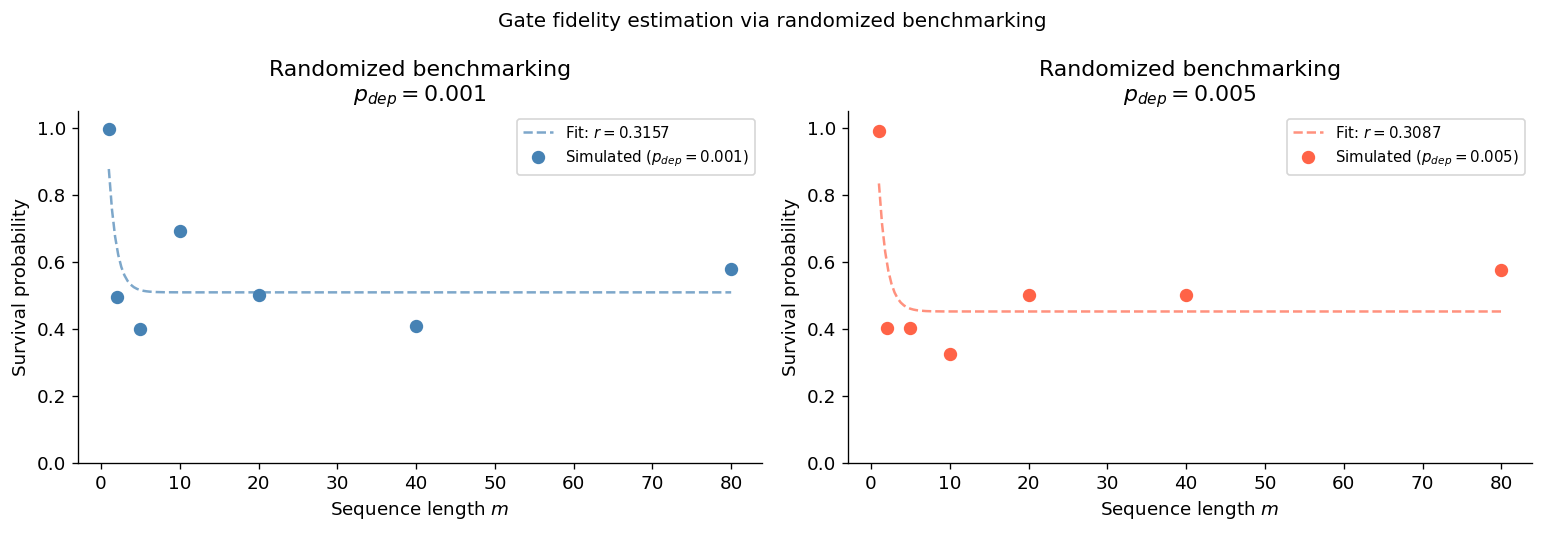


Assignment probability (confusion) matrix A:
  A = [[0.980, 0.030],
       [0.020, 0.970]]

  True distribution:     p(0) = 0.700, p(1) = 0.300
  Measured distribution: p(0) = 0.695, p(1) = 0.305
  Mitigated distribution: p(0) = 0.700, p(1) = 0.300

  Error before mitigation: 0.0100
  Error after  mitigation: 0.0000


In [17]:
# ── Randomized benchmarking-style gate fidelity estimation ───────────────────
# We simulate a sequence of n random Clifford gates (ideal) and measure
# how fidelity drops under a depolarizing noise model.

from qiskit.quantum_info import random_clifford

def rb_sequence(n_gates: int, p_dep: float, n_shots: int = 4096):
    """
    Simulate a randomized benchmarking sequence of length n_gates.
    Returns survival probability (fidelity proxy).
    """
    # Build a circuit of n_gates random single-qubit Cliffords + inverse
    qc = QuantumCircuit(1)
    cliffords = [random_clifford(1) for _ in range(n_gates)]

    # Apply forward sequence
    for cliff in cliffords:
        qc.append(cliff, [0])

    # Append exact inverse (product in reverse order)
    from functools import reduce
    total = reduce(lambda a, b: b.compose(a), cliffords)
    qc.append(total.adjoint(), [0])

    qc.measure_all()

    # Add depolarizing noise
    BASIS = ['h', 's', 'sdg', 'x', 'z', 'sx', 'id', 'rz']
    nm = NoiseModel(basis_gates=BASIS)
    for gate in BASIS:
        nm.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), [gate])

    sim_rb = AerSimulator(noise_model=nm)
    qc_t = transpile(qc, sim_rb, basis_gates=BASIS, optimization_level=0)
    result = sim_rb.run(qc_t, shots=n_shots).result()
    counts = result.get_counts()
    survival = counts.get('0', 0) / n_shots
    return survival


# Sweep over sequence lengths for two error rates
p_list = [1e-3, 5e-3]
seq_lengths = [1, 2, 5, 10, 20, 40, 80]
colors_rb = ['steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, p_dep, col in zip(axes, p_list, colors_rb):
    survivals = []
    for m in seq_lengths:
        # Average over 5 random sequences for stability
        sv = np.mean([rb_sequence(m, p_dep, n_shots=2048) for _ in range(5)])
        survivals.append(sv)

    m_arr = np.array(seq_lengths, dtype=float)
    survivals = np.array(survivals)

    # Fit exponential decay: F(m) = A * (1-2r)^m + B
    from scipy.optimize import curve_fit
    def rb_model(m, A, r, B):
        return A * (1 - 2*r)**m + B
    try:
        popt, _ = curve_fit(rb_model, m_arr, survivals, p0=[0.5, p_dep, 0.5],
                            bounds=([0, 0, 0], [1, 0.5, 1]))
        r_fit = popt[1]
        m_fine = np.linspace(1, 80, 200)
        ax.plot(m_fine, rb_model(m_fine, *popt), '--', color=col, alpha=0.7,
                label=f'Fit: $r = {r_fit:.4f}$')
    except Exception:
        r_fit = None

    ax.plot(seq_lengths, survivals, 'o', color=col, markersize=7, zorder=5,
            label=f'Simulated ($p_{{dep}} = {p_dep}$)')
    ax.set_xlabel('Sequence length $m$')
    ax.set_ylabel('Survival probability')
    ax.set_title(f'Randomized benchmarking\n$p_{{dep}} = {p_dep}$')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)

plt.suptitle("Gate fidelity estimation via randomized benchmarking",
             fontsize=12)
plt.tight_layout()
plt.show()


# ── Readout error: build and correct a confusion matrix ──────────────────────
eps_0 = 0.02   # P(1|0)
eps_1 = 0.03   # P(0|1)

A_matrix = np.array([[1 - eps_0, eps_1],
                     [eps_0,     1 - eps_1]])

print(f"\nAssignment probability (confusion) matrix A:")
print(f"  A = [[{A_matrix[0,0]:.3f}, {A_matrix[0,1]:.3f}],")
print(f"       [{A_matrix[1,0]:.3f}, {A_matrix[1,1]:.3f}]]")

# Simulate measuring a state with known true distribution [0.7, 0.3]
p_true = np.array([0.7, 0.3])
p_meas = A_matrix @ p_true

print(f"\n  True distribution:     p(0) = {p_true[0]:.3f}, p(1) = {p_true[1]:.3f}")
print(f"  Measured distribution: p(0) = {p_meas[0]:.3f}, p(1) = {p_meas[1]:.3f}")

# Mitigate using A_inv
A_inv = np.linalg.inv(A_matrix)
p_mitigated = A_inv @ p_meas
p_mitigated = np.clip(p_mitigated, 0, 1)  # clip negative values from noise
p_mitigated /= p_mitigated.sum()

print(f"  Mitigated distribution: p(0) = {p_mitigated[0]:.3f}, p(1) = {p_mitigated[1]:.3f}")
print(f"\n  Error before mitigation: {np.abs(p_true - p_meas).sum():.4f}")
print(f"  Error after  mitigation: {np.abs(p_true - p_mitigated).sum():.4f}")

## 1.8 Physical Origins of Errors by Hardware Platform

Different quantum computing platforms experience fundamentally different dominant error
mechanisms. Understanding this is essential for choosing which QEC code to use.

### 1.8.1 Superconducting qubits (transmon, fluxonium)

**Working principle:** Josephson junction circuits cooled to $\sim$15 mK. The qubit
is a nonlinear LC oscillator; the $|0\rangle$/$|1\rangle$ states are the ground and
first excited states. Gates are applied via microwave pulses.

| Error type | Physical origin | Typical rate |
|---|---|---|
| $T_1$ relaxation | Coupling to two-level systems (TLS) in substrate/oxide interfaces | $1/(T_1 \cdot f_{\text{gate}}) \sim 10^{-5}$–$10^{-4}$ |
| $T_2$ dephasing | Charge noise, flux noise, photon number fluctuations | $\sim 10^{-4}$–$10^{-3}$ |
| Two-qubit gate error | ZZ crosstalk, leakage to $|2\rangle$ | $10^{-3}$–$10^{-2}$ |
| Readout error | Dispersive readout imperfections | $10^{-2}$–$10^{-3}$ |

**Dominant error: $T_1$ and $T_2$ decoherence from charge/flux noise.**  
$Z$ errors (dephasing) typically dominate over $X$ errors.  
**Favoured QEC code:** Surface code (high threshold $\sim 1\%$, local interactions,
2D connectivity).

**Reference:** Krantz et al., *A Quantum Engineer's Guide to Superconducting Qubits*,
Appl. Phys. Rev. **6**, 021318 (2019).

---

### 1.8.2 Trapped ions (Ca$^+$, Yb$^+$, Ba$^+$)

**Working principle:** Individual atoms confined in electromagnetic traps. Qubits are
encoded in hyperfine or Zeeman electronic levels. Gates use laser or microwave pulses;
two-qubit gates use the collective motional (phonon) modes as a bus.

| Error type | Physical origin | Typical rate |
|---|---|---|
| $T_1$ relaxation | Negligible (optical pumping keeps atoms in hyperfine ground state) | $\sim 10^{-6}$ |
| $T_2$ dephasing | Magnetic field fluctuations, laser frequency noise | $\sim 10^{-5}$–$10^{-4}$ |
| Two-qubit gate error | Motional mode heating, off-resonant excitation | $10^{-3}$–$10^{-4}$ |
| Readout error | State-dependent fluorescence | $10^{-3}$–$10^{-4}$ |
| Atom loss | Background gas collisions | rare, but uncorrectable by Pauli codes |

**Dominant error: laser phase noise ($Z$ dephasing) and motional heating.**  
All-to-all connectivity (no nearest-neighbor constraint).  
**Favoured QEC code:** Steane [[7,1,3]] (CSS code, efficient with all-to-all
connectivity) or color codes.

**Reference:** Bruzewicz et al., *Trapped-ion quantum computing: Progress and challenges*,
Appl. Phys. Rev. **6**, 021314 (2019).

---

### 1.8.3 Neutral atoms (Rydberg, optical tweezers)

**Working principle:** Neutral atoms trapped in optical tweezer arrays. Qubits are
hyperfine levels. Two-qubit gates exploit Rydberg blockade — excitation of one atom
to a high-$n$ Rydberg state prevents excitation of nearby atoms.

| Error type | Physical origin | Typical rate |
|---|---|---|
| Atom loss | Heating from tweezer recapture failure | $10^{-2}$–$10^{-3}$ per gate |
| $T_2$ dephasing | Laser phase noise, light shifts | $10^{-3}$ per gate |
| Rydberg gate error | Finite Rydberg lifetime, Doppler broadening | $5\times 10^{-3}$ |
| Crosstalk | Off-resonant Rydberg excitation | $10^{-3}$ |

**Distinctive feature: atom loss** is a unique error type — the qubit literally
disappears. This is an "erasure error" rather than a Pauli error, and it is actually
*easier* to correct: you know *which* qubit was lost, so the syndrome measurement is
more informative.  
**Favoured QEC code:** Erasure-based codes (e.g., erasure-converted surface codes),
biased-erasure codes.

**Reference:** Evered et al., *High-fidelity parallel entangling gates on a
neutral-atom quantum computer*, Nature **622**, 268–272 (2023).

---

### 1.8.4 Photonic qubits

**Working principle:** Qubits encoded in degrees of freedom of photons (polarization,
time bin, path). Manipulation via linear optics + non-linear elements or measurement-
based schemes (KLM, GKP).

| Error type | Physical origin | Typical rate |
|---|---|---|
| Photon loss | Beam splitter imperfections, fiber loss, detector inefficiency | $10^{-2}$–$10^{-3}$ per component |
| Phase error | Thermal/mechanical instability of optical paths | Low (actively stabilized) |
| Detector dark counts | Thermal noise, afterpulsing | $10^{-5}$–$10^{-6}$ per gate |

**Key difference:** Photonic qubits have essentially infinite $T_1$ and $T_2$ — photons
do not spontaneously decay or dephase at room temperature. The dominant error is
**photon loss**, which behaves as an erasure error.  
**Favoured QEC code:** Bosonic codes (GKP, cat codes), fault-tolerant linear optical
quantum computing (LOQC) schemes.

**Reference:** Bourassa et al., *Blueprint for a Scalable Photonic Fault-Tolerant
Quantum Computer*, Quantum **5**, 392 (2021).

---

### 1.8.5 Silicon spin qubits

**Working principle:** Electron or nuclear spin in a silicon quantum dot. High
compatibility with semiconductor manufacturing. Gates via microwave or baseband pulses.

| Error type | Physical origin | Typical rate |
|---|---|---|
| $T_2^*$ dephasing | Residual $^{29}$Si nuclear spin bath (isotopically purified Si eliminates this) | $10^{-4}$ (nat. Si); $10^{-6}$ (isotopically enriched) |
| Two-qubit gate error | Exchange interaction miscalibration | $10^{-2}$–$10^{-3}$ |
| Readout error | Pauli spin blockade readout | $10^{-2}$ |
| Charge noise | Gate voltage fluctuations | $10^{-3}$–$10^{-4}$ |

**Reference:** Noiri et al., *Fast universal quantum gate above the fault-tolerance threshold in silicon*,
Nature **601**, 338–342 (2022).

---

### 1.8.6 Summary: error types vs hardware platform

The table below summarizes which error types dominate on each platform and which
QEC strategies are best matched to each.

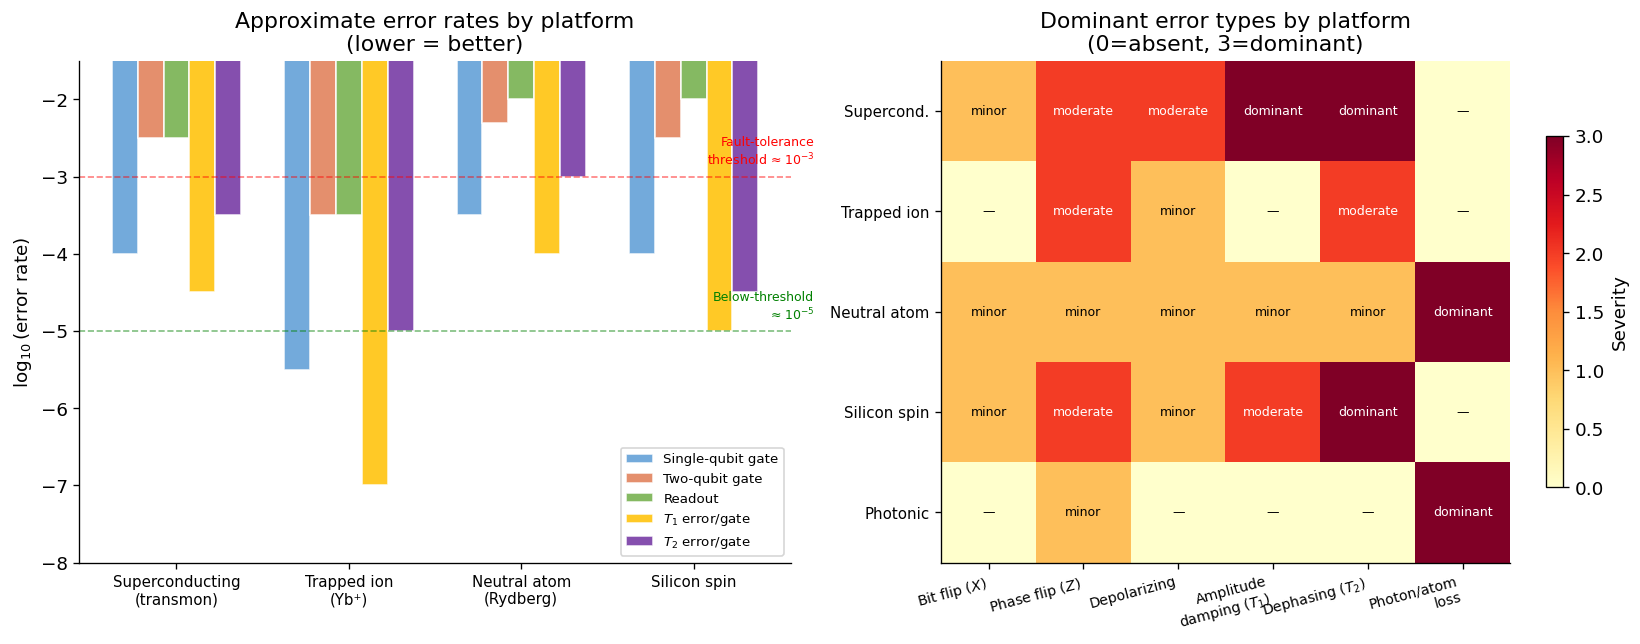


  QEC CODE SELECTION BY HARDWARE PLATFORM

  Superconducting
  ──────────────────────────────────────────────────
  Dominant errors       : T₁, T₂ (Z-biased)
  Connectivity          : 2D nearest-neighbor
  Best QEC codes        : Surface code, Floquet codes
  Key challenge         : Need many physical qubits per logical qubit (~1000)

  Trapped ion
  ──────────────────────────────────────────────────
  Dominant errors       : T₂ dephasing, slow 2-qubit gates
  Connectivity          : All-to-all
  Best QEC codes        : Steane [[7,1,3]], color codes
  Key challenge         : Slow gate speed limits clock rate

  Neutral atom
  ──────────────────────────────────────────────────
  Dominant errors       : Atom loss (erasure), Rydberg gate error
  Connectivity          : Reconfigurable (all-to-all possible)
  Best QEC codes        : Erasure-converted surface/color codes
  Key challenge         : Atom loss not handled by standard Pauli codes

  Photonic
  ───────────────────────────────────

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Left: Error rate comparison bar chart ────────────────────────────────────
platforms = ['Superconducting\n(transmon)', 'Trapped ion\n(Yb⁺)',
             'Neutral atom\n(Rydberg)', 'Silicon spin']

# Approximate log10 of typical single-qubit error rates
data = {
    'Single-qubit gate': [-4.0, -5.5, -3.5, -4.0],
    'Two-qubit gate':    [-2.5, -3.5, -2.3, -2.5],
    'Readout':           [-2.5, -3.5, -2.0, -2.0],
    '$T_1$ error/gate':  [-4.5, -7.0, -4.0, -5.0],
    '$T_2$ error/gate':  [-3.5, -5.0, -3.0, -4.5],
}

ax1 = axes[0]
x = np.arange(len(platforms))
width = 0.15
offsets = np.linspace(-(len(data)-1)/2, (len(data)-1)/2, len(data)) * width
colors_bar = ['#5b9bd5', '#e07b54', '#70ad47', '#ffc000', '#7030a0']

for (label, vals), offset, col in zip(data.items(), offsets, colors_bar):
    ax1.bar(x + offset, vals, width, label=label, color=col, alpha=0.85, edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(platforms, fontsize=9)
ax1.set_ylabel('$\\log_{10}$(error rate)')
ax1.set_title('Approximate error rates by platform\n(lower = better)')
ax1.legend(fontsize=8, loc='lower right')
ax1.set_ylim(-8, -1.5)
ax1.axhline(-3, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax1.text(3.7, -2.85, 'Fault-tolerance\nthreshold ≈ $10^{-3}$',
         fontsize=7.5, color='red', ha='right')
ax1.axhline(-5, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax1.text(3.7, -4.85, 'Below-threshold\n≈ $10^{-5}$',
         fontsize=7.5, color='green', ha='right')


# ── Right: Error type heatmap ─────────────────────────────────────────────────
ax2 = axes[1]

error_types = ['Bit flip ($X$)', 'Phase flip ($Z$)', 'Depolarizing',
               'Amplitude\ndamping ($T_1$)', 'Dephasing ($T_2$)',
               'Photon/atom\nloss']
platforms_short = ['Supercond.', 'Trapped ion', 'Neutral atom', 'Silicon spin', 'Photonic']

# Severity matrix: 0=absent, 1=minor, 2=moderate, 3=dominant
severity = np.array([
#   X    Z    Dep  T1   T2   Loss
    [1,   2,   2,   3,   3,   0],   # Superconducting
    [0,   2,   1,   0,   2,   0],   # Trapped ion
    [1,   1,   1,   1,   1,   3],   # Neutral atom
    [1,   2,   1,   2,   3,   0],   # Silicon spin
    [0,   1,   0,   0,   0,   3],   # Photonic
])

cmap = plt.cm.YlOrRd
im = ax2.imshow(severity, cmap=cmap, vmin=0, vmax=3, aspect='auto')

ax2.set_xticks(range(len(error_types)))
ax2.set_xticklabels(error_types, fontsize=8.5, rotation=15, ha='right')
ax2.set_yticks(range(len(platforms_short)))
ax2.set_yticklabels(platforms_short, fontsize=9)
ax2.set_title('Dominant error types by platform\n(0=absent, 3=dominant)')

for i in range(len(platforms_short)):
    for j in range(len(error_types)):
        val = severity[i, j]
        label_map = {0: '—', 1: 'minor', 2: 'moderate', 3: 'dominant'}
        text_col = 'white' if val >= 2 else 'black'
        ax2.text(j, i, label_map[val], ha='center', va='center',
                 fontsize=7.5, color=text_col)

plt.colorbar(im, ax=ax2, shrink=0.7, label='Severity')

plt.tight_layout()
plt.show()


# ── Print QEC code recommendation summary ────────────────────────────────────
summary = {
    'Superconducting': {
        'Dominant errors': 'T₁, T₂ (Z-biased)',
        'Connectivity': '2D nearest-neighbor',
        'Best QEC codes': 'Surface code, Floquet codes',
        'Key challenge': 'Need many physical qubits per logical qubit (~1000)',
    },
    'Trapped ion': {
        'Dominant errors': 'T₂ dephasing, slow 2-qubit gates',
        'Connectivity': 'All-to-all',
        'Best QEC codes': 'Steane [[7,1,3]], color codes',
        'Key challenge': 'Slow gate speed limits clock rate',
    },
    'Neutral atom': {
        'Dominant errors': 'Atom loss (erasure), Rydberg gate error',
        'Connectivity': 'Reconfigurable (all-to-all possible)',
        'Best QEC codes': 'Erasure-converted surface/color codes',
        'Key challenge': 'Atom loss not handled by standard Pauli codes',
    },
    'Photonic': {
        'Dominant errors': 'Photon loss',
        'Connectivity': 'Linear optics, measurement-based',
        'Best QEC codes': 'GKP bosonic, cat codes, LOQC schemes',
        'Key challenge': 'Non-deterministic 2-qubit gates',
    },
}

print("\n" + "="*65)
print("  QEC CODE SELECTION BY HARDWARE PLATFORM")
print("="*65)
for platform, info in summary.items():
    print(f"\n  {platform}")
    print(f"  {'─'*50}")
    for key, val in info.items():
        print(f"  {key:<22}: {val}")

## 1.9 Chapter Summary

This chapter established the physical and mathematical foundations of quantum computing
errors. The key results are:

**Conceptual foundations:**
- Quantum errors are continuous and arise from any environmental interaction.
- The no-cloning theorem forbids the classical solution (direct copying).
- Any error decomposes into a combination of Pauli operators $\{I, X, Y, Z\}$ — this
  **discretization of errors** is the reason QEC is possible.

**Error types and their Kraus operators:**

| Error | Kraus operators | Bloch sphere effect |
|---|---|---|
| Bit flip ($X$) | $\sqrt{1-p}\,I,\;\sqrt{p}\,X$ | Squeeze toward $x$-axis |
| Phase flip ($Z$) | $\sqrt{1-p}\,I,\;\sqrt{p}\,Z$ | Squeeze toward $z$-axis |
| Bit-phase flip ($Y$) | $\sqrt{1-p}\,I,\;\sqrt{p}\,Y$ | Squeeze toward $y$-axis |
| Depolarizing | $\sqrt{1-3p/4}\,I,\;\frac{\sqrt{p}}{2}\{X,Y,Z\}$ | Uniform contraction |
| Amplitude damping | $K_0=\begin{pmatrix}1&0\\0&\sqrt{1-p}\end{pmatrix},\;K_1=\begin{pmatrix}0&\sqrt{p}\\0&0\end{pmatrix}$ | Collapse toward $|0\rangle$ |

**Decoherence timescales:**
$$\frac{1}{T_2} = \frac{1}{2T_1} + \frac{1}{T_\phi}, \qquad T_2 \leq 2T_1$$

**Hardware comparison:**
- Superconducting → surface codes (2D, high threshold, $Z$-dominated noise)
- Trapped ion → Steane/color codes (all-to-all connectivity, very low error rates)
- Neutral atom → erasure codes (loss is the dominant error, not Pauli errors)
- Photonic → bosonic codes (GKP, cat) (photon loss, not $T_1/T_2$)

---

## Full References

| # | Reference |
|---|---|
| [1] | Nielsen, M. A. & Chuang, I. L. *Quantum Computation and Quantum Information*. Cambridge University Press, 2010. |
| [2] | Quillen, A. C. *Introducing Quantum Error Correction* (PHY265 lecture notes). University of Rochester, 2025. https://astro.pas.rochester.edu/~aquillen/phy265/lectures/QI_E.pdf |
| [3] | Preskill, J. *Lecture Notes for Ph219/CS219: Quantum Information, Chapter 3*. Caltech, 2015. https://www.preskill.caltech.edu/ph219/chap3_15.pdf |
| [4] | Wootters, W. K. & Zurek, W. H. A single quantum cannot be cloned. *Nature* **299**, 802–803 (1982). DOI: 10.1038/299802a0 |
| [5] | Lindblad, G. On the generators of quantum dynamical semigroups. *Commun. Math. Phys.* **48**, 119–130 (1976). DOI: 10.1007/BF01608499 |
| [6] | Shor, P. W. Scheme for reducing decoherence in quantum computer memory. *Phys. Rev. A* **52**, R2493 (1995). DOI: 10.1103/PhysRevA.52.R2493 |
| [7] | Steane, A. M. Error correcting codes in quantum theory. *Phys. Rev. Lett.* **77**, 793 (1996). DOI: 10.1103/PhysRevLett.77.793 |
| [8] | Gottesman, D. *Stabilizer Codes and Quantum Error Correction* (PhD thesis). Caltech, 1997. arXiv:quant-ph/9705052 |
| [9] | Breuer, H.-P. & Petruccione, F. *The Theory of Open Quantum Systems*. Oxford University Press, 2002. |
| [10] | Krantz, P. et al. A quantum engineer's guide to superconducting qubits. *Appl. Phys. Rev.* **6**, 021318 (2019). DOI: 10.1063/1.5089550 |
| [11] | Bruzewicz, C. D. et al. Trapped-ion quantum computing: Progress and challenges. *Appl. Phys. Rev.* **6**, 021314 (2019). DOI: 10.1063/1.5088164 |
| [12] | Evered, S. J. et al. High-fidelity parallel entangling gates on a neutral-atom quantum computer. *Nature* **622**, 268–272 (2023). DOI: 10.1038/s41586-023-06481-y |
| [13] | Noiri, A. et al. Fast universal quantum gate above the fault-tolerance threshold in silicon. *Nature* **601**, 338–342 (2022). DOI: 10.1038/s41586-021-04182-y |
| [14] | Bourassa, J. E. et al. Blueprint for a scalable photonic fault-tolerant quantum computer. *Quantum* **5**, 392 (2021). DOI: 10.22331/q-2021-02-04-392 |
| [15] | Wikipedia: *Quantum error correction*. https://en.wikipedia.org/wiki/Quantum_error_correction |
| [16] | Qiskit documentation: https://qiskit.org/documentation/ |
| [17] | Qiskit QEC community: https://github.com/qiskit-community/qiskit-qec |
| [18] | Mitiq documentation: https://mitiq.readthedocs.io/en/stable/ |
```

---

That's the complete Chapter 1. Here's a summary of what's in each code cell so you know what to expect when you run it:

| Cell | What it does | Key library |
|---|---|---|
| Cell 2 | All imports | qiskit, qiskit-aer, numpy, scipy, matplotlib |
| Cell 5 | Pauli orthonormality check, Bloch sphere helper, Pauli action on $\|+\rangle$ | numpy, matplotlib |
| Cell 7 | Bit-flip channel simulation, Bloch contraction, Qiskit X-error injection | qiskit-aer |
| Cell 9 | Phase-flip channel, invisibility to Z-basis measurement, side-by-side comparison | numpy, qiskit |
| Cell 11 | Depolarizing + Y channels, purity comparison | numpy, matplotlib |
| Cell 13 | Full Lindblad ODE simulation, Bloch decay curves, analytical vs numerical comparison | scipy |
| Cell 14 | Qiskit thermal relaxation noise model, fidelity vs idle gates | qiskit-aer |
| Cell 16 | Randomized benchmarking simulation, readout confusion matrix + mitigation | qiskit, scipy |
| Cell 18 | Platform error rate bar chart + dominance heatmap + QEC recommendation table | matplotlib |

One practical note: Cell 16's RB simulation runs 5 random Clifford sequences per depth — it takes 30–60 seconds. If you want it faster, reduce `n_shots` to 512 or limit the `seq_lengths` range.